# Лабораторная 2
## Исследование Variance Gamma Distribution

### 1. Определение случайных величин. Плотность распределения, функция распределения и характеристическая функция.

Случайная величина $X$ имеет распределение Variance Gamma, если: $$X \sim \operatorname{VG}(\mu, \theta, \sigma, \nu)$$
где $\mu \in \mathbb{R}$ - параметр сдвига, $\theta \in \mathbb{R}$ - параметр асимметрии, $\sigma > 0$ - параметр масштаба, $\nu > 0$ - параметр формы.

$$f(x) = \frac{1}{\sigma\sqrt{\pi\nu}\,2^{1/\nu-1}\,\Gamma(1/\nu)}
       \left( \frac{|x-\mu|}{\sigma} \right)^{1/\nu-1/2}
       K_{1/\nu-1/2}\!\left( \frac{|x-\mu|}{\sigma} \right).$$

$$F(x) = \int_{-\infty}^{x} f(t)\,dt.$$
$$\varphi(t) = \mathbb{E}\left[e^{itX}\right] = e^{i\mu t} \left( 1 - i\theta\nu t + \frac{\sigma^2\nu}{2}\,t^2 \right)^{-1/\nu}, \quad t \in \mathbb{R}.$$

Подключение нужных библиотек.

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.optimize import fsolve

MU: float = 0
THETA: float = 0
SIGMA: float = 1
NU: float = 1
MU_ARR: list[float] = [-2, 0, 2]
THETA_ARR: list[float] = [0, 1, 2]
SIGMA_ARR: list[float] = [1, 2, 3]
NU_ARR: list[float] = [0.5, 1, 1.5]

Класс для работы с логнормальным распределением: заданные плотность распределения, функция распределения и алгоритм, используемый для генерации случайных величин из распределения Variance Gamma.

In [47]:
from scipy import special

class VarianceGamma:
    def __init__(self, mu: float, theta: float, sigma: float, nu: float):
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.nu = nu

    def rvs(self, size=1000):
        """
        Генерация случайных чисел из VG распределения
        """
        # 1. Генерируем случайное время из гамма-распределения
        # Параметры: shape = 1/nu, scale = nu [citation:3]
        g = np.random.gamma(shape=1/self.nu, scale=self.nu, size=size)
        
        # 2. Условное нормальное распределение:
        # VG = theta * g + sigma * sqrt(g) * N(0,1)
        # где g - сгенерированное гамма-время
        normal = np.random.normal(0, 1, size)
        vg = self.theta * g + self.sigma * np.sqrt(g) * normal + self.mu
        
        return vg

    def pdf(self, x: np.ndarray):
        mu = self.mu
        sigma = self.sigma
        nu = self.nu
        theta = self.theta
        
        temp1 = 2.0 / ( sigma * (2.0 *np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
        temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
        temp3 = np.exp(theta*(x-mu)/sigma**2) * abs(x-mu)**(1/nu - 0.5)
        temp4 = special.kv(1/nu - 0.5, abs(x-mu)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
        return temp1*temp2*temp3*temp4

    def cdf_one_point(self, x: float):
        return quad(self.pdf, -np.inf, x)[0]
    
    def cdf(self, x: np.ndarray):
        x = np.asarray(x)
        res = np.empty_like(x, dtype=float)
        # Используем ndenumerate для обхода элементов любой формы
        for idx, xi in np.ndenumerate(x):
            res[idx] = self.cdf_one_point(xi)
        return res
    
    def ppf(self, p: float, tol: float = 1e-6, max_iter: int = 50) -> float:
        # Определяем направление поиска
        if p > 0.5:
            # Ищем справа от mu
            x_left = self.mu
            x_right = self.mu + self.sigma  # начальное приближение
            # Расширяем правую границу, пока CDF(x_right) < p
            for _ in range(max_iter):
                if self.cdf_one_point(x_right) >= p:
                    break
                x_right += self.sigma * (2 ** _)  # экспоненциальное расширение
            else:
                # Если не нашли за max_iter, пробуем очень широкий интервал
                x_right = self.mu + 1e6
        else:
            # Ищем слева от mu
            x_left = self.mu - self.sigma
            x_right = self.mu
            for _ in range(max_iter):
                if self.cdf_one_point(x_left) <= p:
                    break
                x_left -= self.sigma * (2 ** _)
            else:
                x_left = self.mu - 1e6

        # Убедимся, что знаки разные (если нет, расширяем ещё)
        f_left = self.cdf_one_point(x_left) - p
        f_right = self.cdf_one_point(x_right) - p
        if f_left * f_right > 0:
            # В极端 случае расширяем в обе стороны
            x_left = self.mu - 1e6
            x_right = self.mu + 1e6

        sol = root_scalar(lambda x: self.cdf_one_point(x) - p,
                        bracket=[x_left, x_right],
                        method='brentq',
                        xtol=tol)
        if sol.converged:
            return sol.root
        else:
            # Последняя попытка: очень широкий интервал
            sol = root_scalar(lambda x: self.cdf_one_point(x) - p,
                            bracket=[-1e6, 1e6],
                            method='brentq',
                            xtol=tol)
            if sol.converged:
                return sol.root
            else:
                raise RuntimeError(f"Не удалось вычислить квантиль для p={p}, mu={self.mu}, theta={self.theta}")

### 2. Графики плотности и функции распределения.

Зафиксируем $\sigma=1, \theta=0, \nu=1$ и рассмотрим три значения $\mu = -2, 0, 2$. Построим плотности и функции распределения:

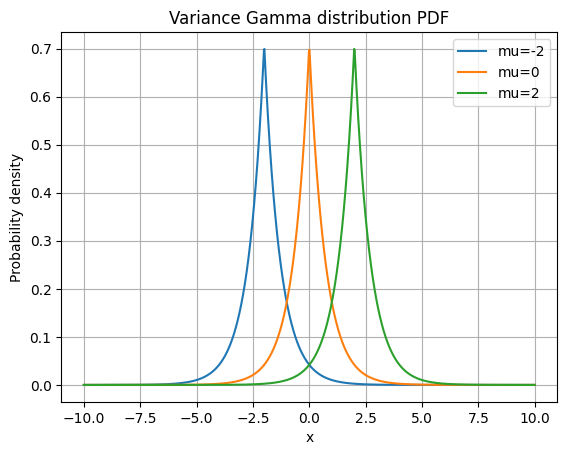

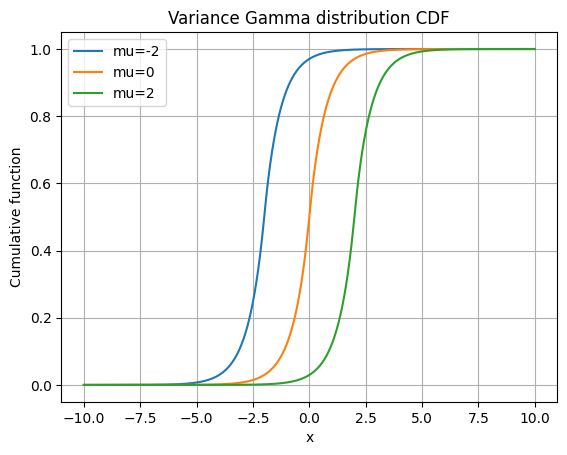

In [23]:
x: np.ndarray = np.linspace(-10, 10, 1000)

for i in MU_ARR:
    distr = VarianceGamma(i, THETA, SIGMA, NU)
    y = distr.pdf(x)
    plt.plot(x, y, label=f"mu={i}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Variance Gamma distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in MU_ARR:
    distr = VarianceGamma(i, THETA, SIGMA, NU)
    y = distr.cdf(x)
    plt.plot(x, y, label=f"mu={i}")
plt.xlabel("x")
plt.ylabel("Cumulative function")
plt.title("Variance Gamma distribution CDF")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: график смещается вдоль оси $x$.
2. Функция распределения: также смещается вдоль оси $x$.

Зафиксируем $\mu=0, \theta=0, \nu=1$ и рассмотрим три значения $\sigma = 0.2, 1, 2$. Построим плотности и функции распределения:

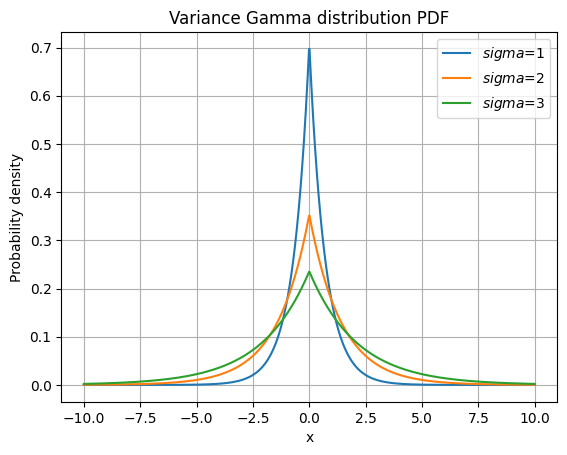

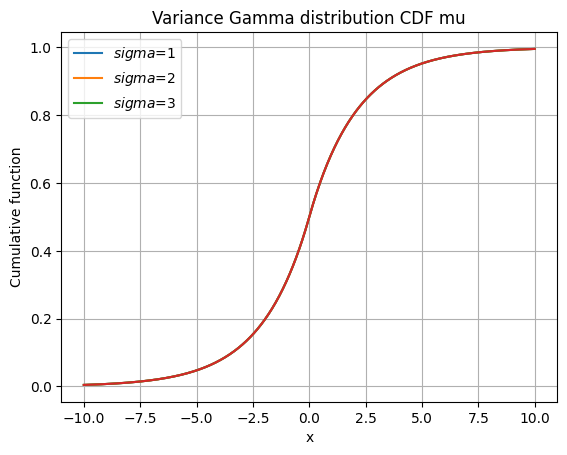

In [24]:
x: np.ndarray = np.linspace(-10, 10, 1000)

for i in SIGMA_ARR:
    distr = VarianceGamma(MU, THETA, i, NU)
    y = distr.pdf(x)
    plt.plot(x, y, label=rf"$sigma$={i}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Variance Gamma distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in SIGMA_ARR:
    lognorm_distr = VarianceGamma(MU, THETA, i, NU)
    y = distr.cdf(x)
    plt.plot(x, y, label=rf"$sigma$={i}")
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("Cumulative function")
plt.title("Variance Gamma distribution CDF mu")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: с ростом $\sigma$ растёт пик, соответственно хвосты становятся легче. Изменяется только высота графика.
2. Функция распределения: никак не влияет параметр (либо ошибка построения графика в пакете).

Зафиксируем $\sigma=1, \mu=0, \nu=1$ и рассмотрим три значения $\theta = 0, 1, 2$. Построим плотности и функции распределения:

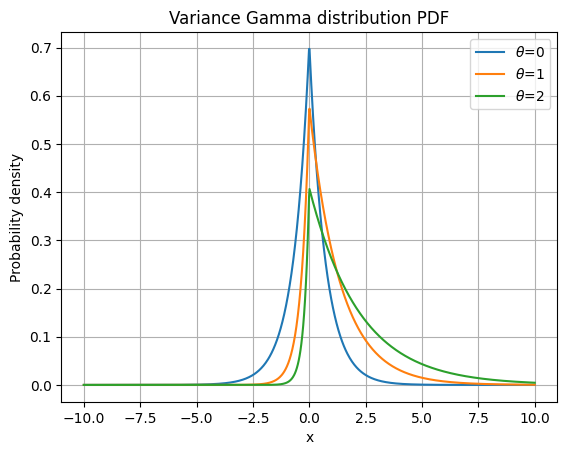

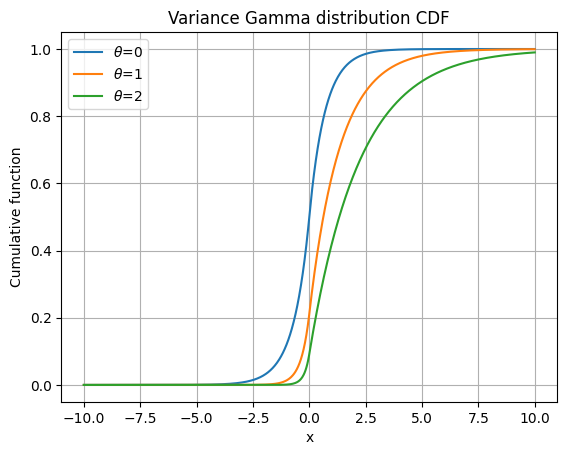

In [25]:
x: np.ndarray = np.linspace(-10, 10, 1000)

for i in THETA_ARR:
    distr = VarianceGamma(MU, i, SIGMA, NU)
    y = distr.pdf(x)
    plt.plot(x, y, label=rf"$\theta$={i}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Variance Gamma distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in THETA_ARR:
    distr = VarianceGamma(MU, i, SIGMA, NU)
    y = distr.cdf(x)
    plt.plot(x, y, label=rf"$\theta$={i}")
plt.xlabel("x")
plt.ylabel("Cumulative function")
plt.title("Variance Gamma distribution CDF")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: $\theta$ также влияет на асимметрию: с ростом всё больше значений находится правее, плотность распределения перекашивается вправо. С ростом $\theta$ растёт пик, соответственно хвосты становятся легче.
2. Функция распределения: с ростом $\theta$ график становится более пологим, функция распределения начинает расти медленнее.

Зафиксируем $\sigma=1, \mu=0, \theta=0$ и рассмотрим три значения $\nu = 0.5, 1, 1.5$. Построим плотности и функции распределения:

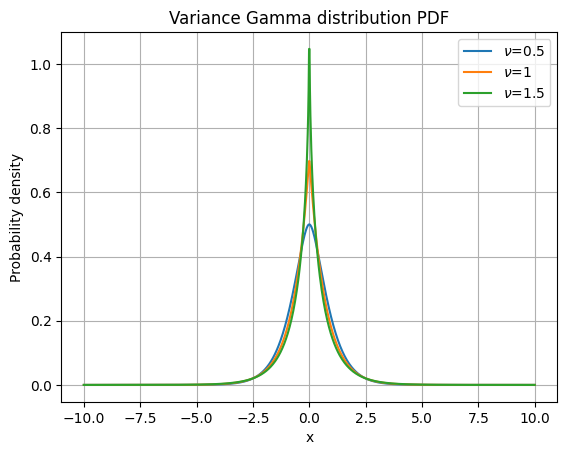

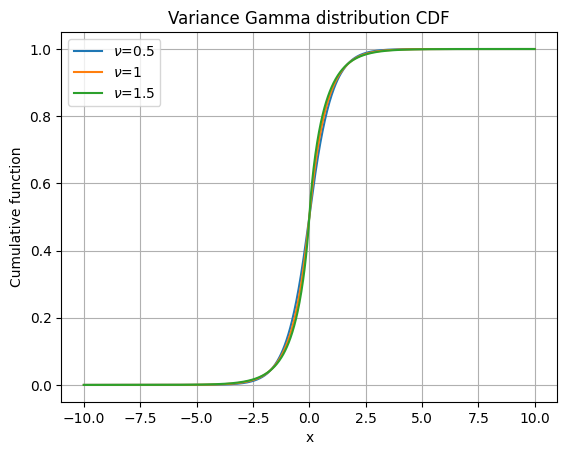

In [26]:

x: np.ndarray = np.linspace(-10, 10, 1000)

for i in NU_ARR:
    distr = VarianceGamma(MU, THETA, SIGMA, i)
    y = distr.pdf(x)
    plt.plot(x, y, label=rf"$\nu$={i}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Variance Gamma distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in NU_ARR:
    distr = VarianceGamma(MU, THETA, SIGMA, i)
    y = distr.cdf(x)
    plt.plot(x, y, label=rf"$\nu$={i}")
plt.xlabel("x")
plt.ylabel("Cumulative function")
plt.title("Variance Gamma distribution CDF")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: $\nu$ влияет на высоту пика.
2. Функция распределения: почти никак не изменяется, наблюдаются лишь незначительные изменения скорости роста ввиду увеличения пика графика плотности распределения.

## 3. Моделирование случайной выборки. Точность моделирования (критерии). Алгоритм моделирования.

Алгоритм:
1. Генерируется случайное время из гамма-распределения $g$.
2. Подставляется в условное нормальное распределение: $\text{VG} = \theta \cdot g + \sigma \cdot \sqrt{g} \cdot \mathcal{N}(0,1)$.

Для проверки гипотезы $H_0$: сгенерированная выборка соответствует Variance Gamma распределению с параметрами $\mu, \theta, \sigma, \nu$ используются статистический критерий Колмогорова-Смирнова с уровнем значимости $\alpha=0.95$.

In [68]:
distr = VarianceGamma(MU, THETA, SIGMA, NU)
sample = distr.rvs(1000)

In [28]:
ks_stat, ks_p_value = stats.kstest(sample, distr.cdf)
print(f"Kolmogorov-Smirnov test: statistic={ks_stat}, p-value={ks_p_value}")

Kolmogorov-Smirnov test: statistic=0.01587335501291609, p-value=0.9592208204058934


## 4. Оценка параметров распределения. Точность оценивания (критерии).

Параметрами распределения являются $\mu, \theta, \sigma, \nu$, находятся их оценки.

In [69]:
def moments_method(sample: np.ndarray):
    sample_np = np.asarray(sample)
    m1 = np.mean(sample_np)
    m2 = np.mean((sample_np - m1)**2)
    m3 = np.mean((sample_np - m1)**3)
    m4 = np.mean((sample_np - m1)**4)

    def system(vars):
        mu, theta, sigma, nu = vars
        eq1 = -m1 + mu + theta
        eq2 = -m2 + sigma ** 2 + theta ** 2 * nu
        eq3 = -m3 + 2 * theta**3 * nu**2 + 3 * theta * sigma**2 * nu
        eq4 = -m4 + 3*sigma**4*nu + 12 * theta**2 * nu**2 + 6 * theta**4 * nu**3 + 3 * (sigma**2 + theta**2 * nu)**2
        return [eq1, eq2, eq3, eq4]
    
    root = fsolve(system, [0, 0, 1, 1])
    
    return {"mu": root[0], "theta": root[1], "sigma": root[2], "nu": root[3]}

moments = moments_method(sample)
print(rf"$\mu$ = {moments["mu"]}, $\theta$ = {moments["theta"]}, $\sigma$ = {moments["sigma"]}, $\nu$ = {moments["nu"]}, ")

$\mu$ = -0.027816745956380968, $\theta$ = -0.03590181109807777, $\sigma$ = 1.0733620458237418, $\nu$ = 0.9967145087135107, 


## 5. Оценка плотности распределения

Для оценки плотности распределения используется ядерная оценка с гауссовским ядром.

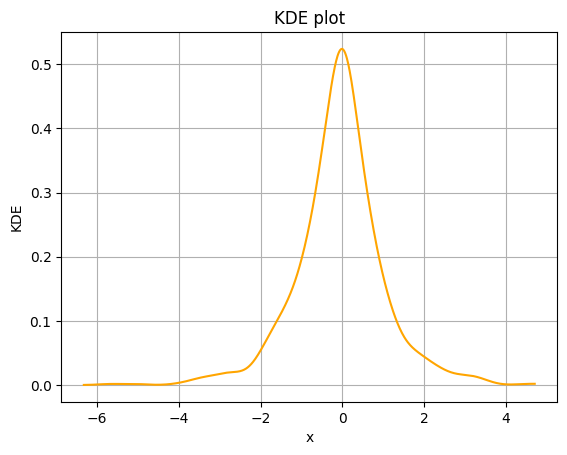

In [70]:
kde = stats.gaussian_kde(sample)
density = kde.evaluate(x)

plt.plot(x, density, color="orange")
plt.xlabel("x")
plt.ylabel("KDE")
plt.title("KDE plot")
plt.grid()
plt.show()

## 6. На одном графике: плотность распределения, гистограмма и оценка плотности распределения

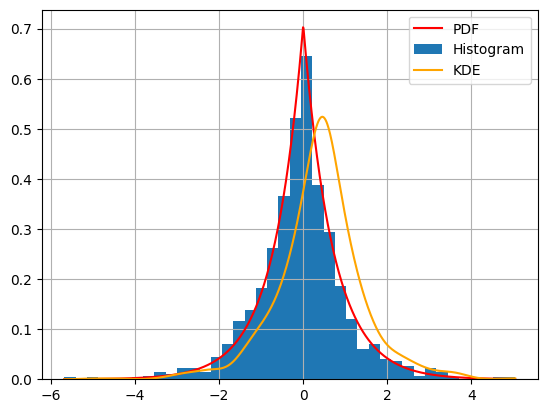

In [71]:
x = np.linspace(min(sample), max(sample), 1000)
pdf = distr.pdf(x)

num_bins = math.trunc(max(sample) - min(sample)) * 4

plt.plot(x, pdf, color="red", label="PDF")
plt.hist(sample, bins=num_bins, density=True, label="Histogram")
plt.plot(x, density, color="orange", label="KDE")

plt.grid()
plt.legend()
plt.show()

## 7. Исследовать квантиль распределения в зависимости от параметров распределения. Вычислить VaR.

Зафиксируем $\theta=0, \sigma=1, \nu=1$. Построим график зависимости квантиля распределения от $\mu$. Возьмём $p=0.95$

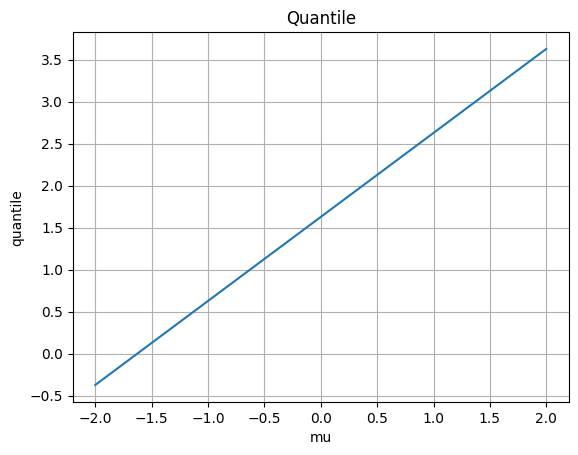

In [42]:
p = 0.95
mu_values = np.linspace(-2, 2, 100)
quantiles: list[float] = []
for mu in mu_values:
    vg = VarianceGamma(mu, THETA, SIGMA, NU)
    quantiles.append(vg.ppf(p))
plt.plot(mu_values, quantiles)
plt.xlabel("mu")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0, \sigma=1, \nu=1$. Построим график зависимости квантиля распределения от $\theta$. Возьмём $p=0.95$

/tmp/ipykernel_2961/175166145.py:36: RuntimeWarning: invalid value encountered in scalar multiply
  return temp1*temp2*temp3*temp4
/tmp/ipykernel_2961/175166145.py:39: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self.pdf, -np.inf, x)[0]


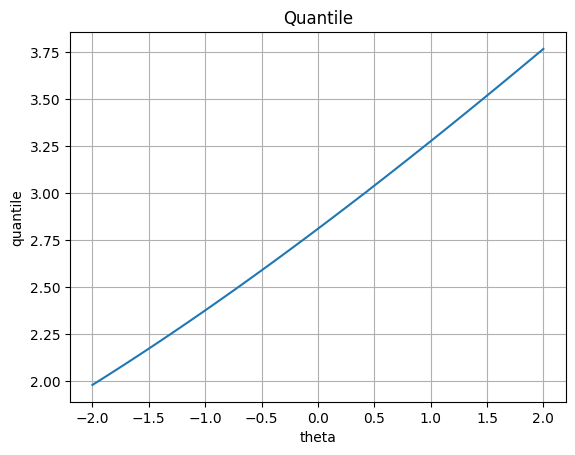

In [51]:
p = 0.95
theta_values = np.linspace(0.2, 1, 100)
quantiles: list[float] = []
for theta in theta_values:
    vg = VarianceGamma(MU, theta, SIGMA, NU)
    quantiles.append(vg.ppf(p))
plt.plot(mu_values, quantiles)
plt.xlabel("theta")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0, \theta=0, \nu=1$. Построим график зависимости квантиля распределения от $\sigma$. Возьмём $p=0.95$

/tmp/ipykernel_2961/1675397094.py:36: RuntimeWarning: invalid value encountered in scalar multiply
  return temp1*temp2*temp3*temp4
/tmp/ipykernel_2961/1675397094.py:39: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self.pdf, -np.inf, x)[0]


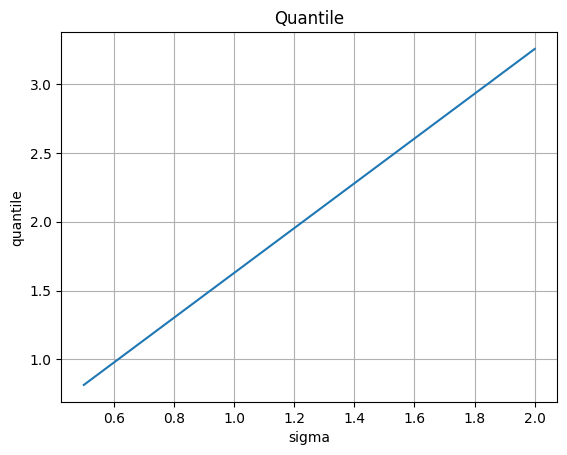

In [44]:
p = 0.95
sigma_values = np.linspace(0.5, 2, 70)
quantiles: list[float] = []
for sigma in sigma_values:
    vg = VarianceGamma(MU, THETA, sigma, NU)
    quantiles.append(vg.ppf(p))
plt.plot(sigma_values, quantiles)
plt.xlabel("sigma")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0, \sigma=1, \theta=0$. Построим график зависимости квантиля распределения от $\nu$. Возьмём $p=0.95$

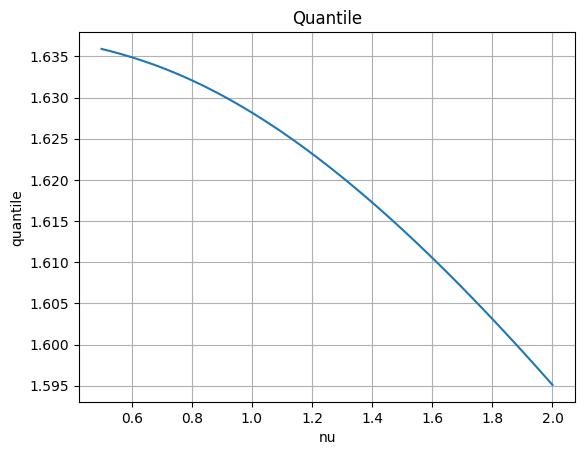

In [45]:
p = 0.95
nu_values = np.linspace(0.5, 2, 70)
quantiles: list[float] = []
for nu in nu_values:
    vg = VarianceGamma(MU, THETA, SIGMA, nu)
    quantiles.append(vg.ppf(p))
plt.plot(nu_values, quantiles)
plt.xlabel("nu")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Вычислим VaR:

In [72]:
p = 0.95

vg = VarianceGamma(MU, THETA, SIGMA, NU)
var = vg.ppf(p)
print(f"  VaR_{p*100:.0f}% = {var:.4f}")

  VaR_95% = 1.6282


/tmp/ipykernel_2961/175166145.py:36: RuntimeWarning: invalid value encountered in scalar multiply
  return temp1*temp2*temp3*temp4
/tmp/ipykernel_2961/175166145.py:39: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self.pdf, -np.inf, x)[0]
